In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

import warnings
warnings.filterwarnings('ignore')

In [25]:
df = pd.read_csv("IRIS.csv")
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [26]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB


In [27]:
df['species'].value_counts()

species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

In [28]:
df.isnull().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

In [29]:
# Sayısal sütunlar için medyan ile doldurma
for col in df.select_dtypes(include=["number"]).columns:
    df[col] = df[col].fillna(df[col].median())

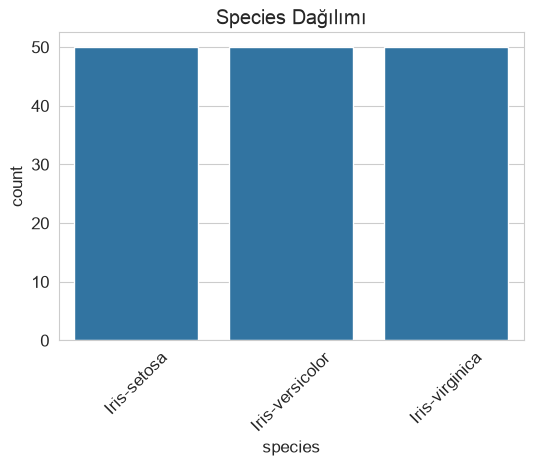

In [30]:
# 4) Tür dağılımı
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="species")
plt.title("Species Dağılımı")
plt.xticks(rotation=45)
plt.show()


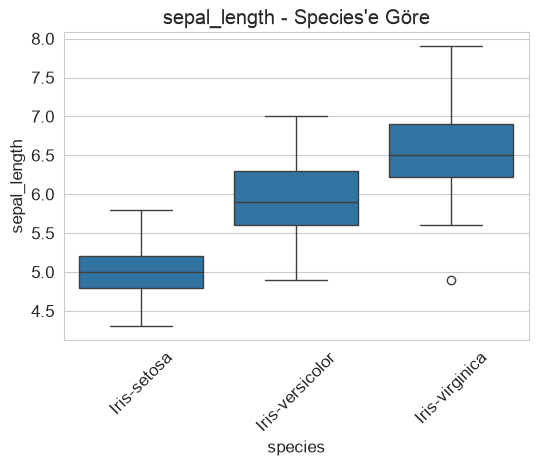

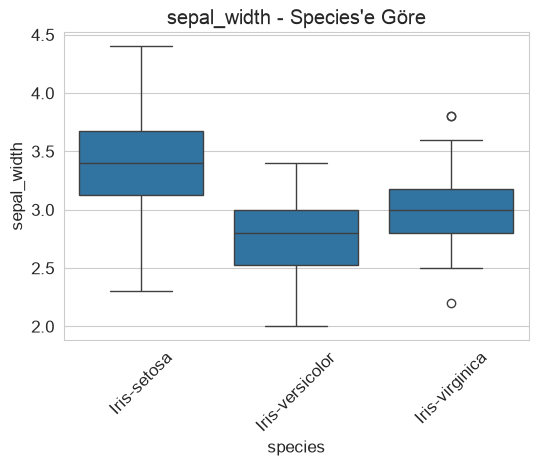

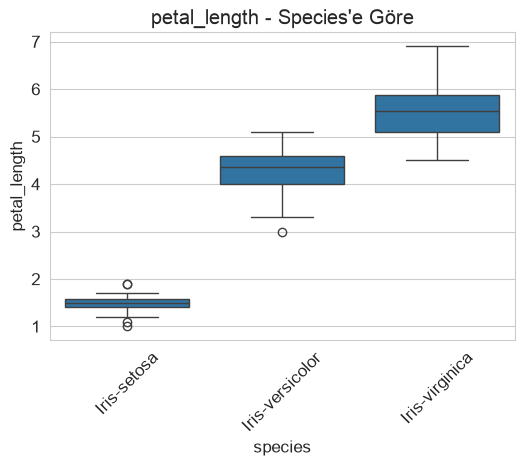

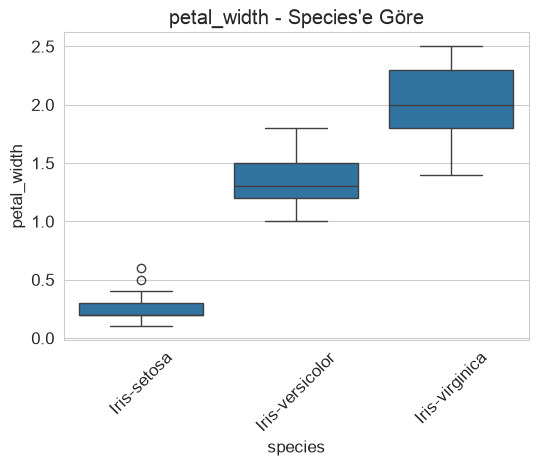

In [31]:
# 5) Sayısal sütunların kutu grafiği
numeric_cols = df.select_dtypes(include=["number"]).columns
for col in numeric_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=df, x="species", y=col)
    plt.title(f"{col} - Species'e Göre")
    plt.xticks(rotation=45)
    plt.show()

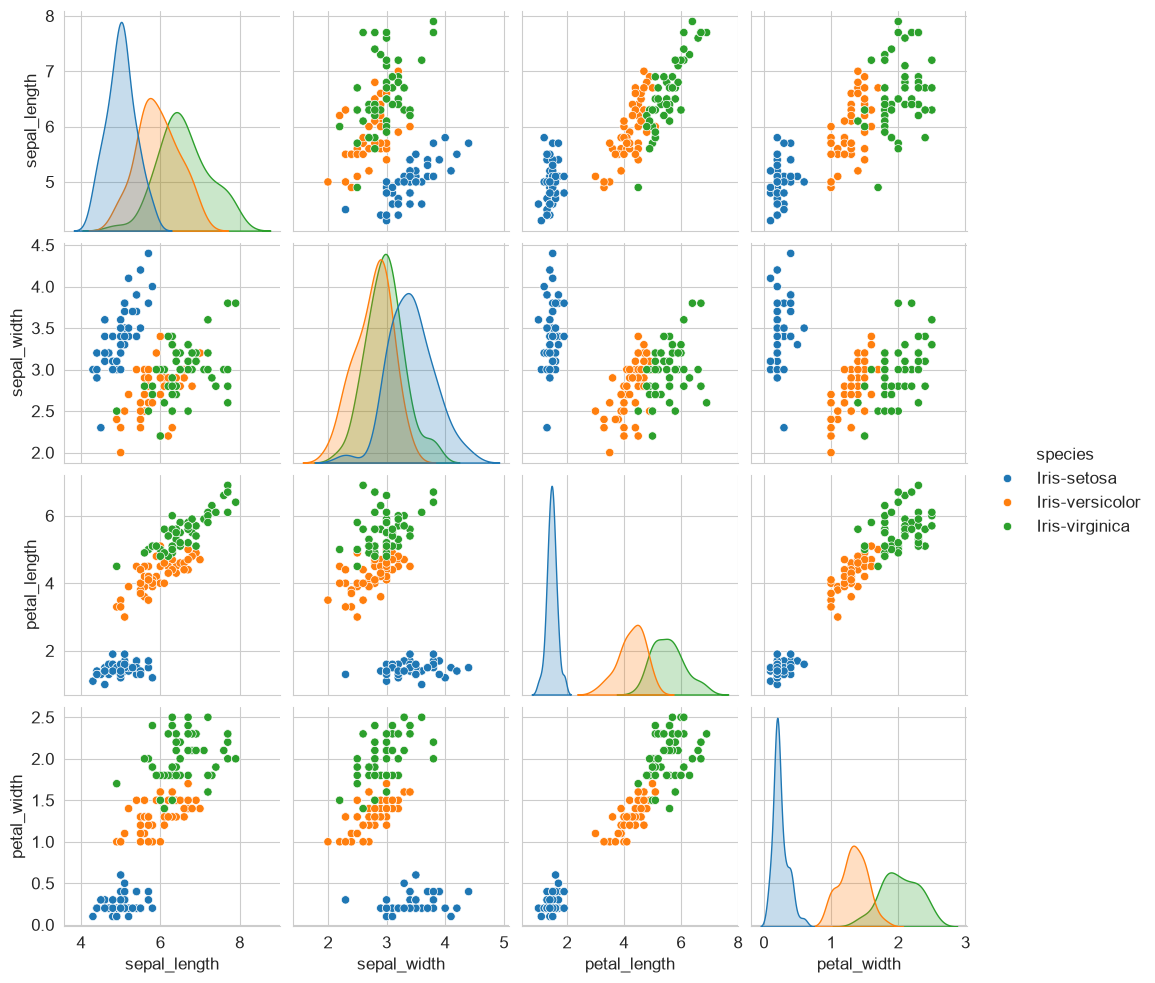

In [32]:

# 6) Sayısal kolonlar arası ilişki
sns.pairplot(df, hue="species", diag_kind="kde")
plt.show()

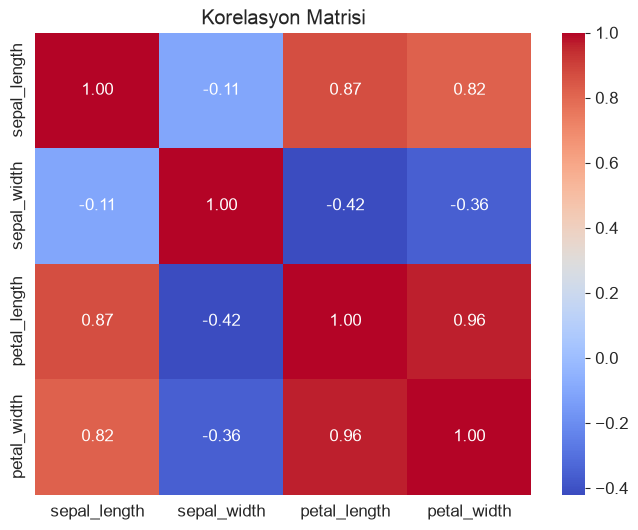

In [33]:
# 7) Korelasyon ısı haritası
corr = df.select_dtypes(include=["number"]).corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Korelasyon Matrisi")
plt.show()



In [34]:
target = 'petal_length'
corr_with_target = corr[target].sort_values(ascending=False)
print('WITH PETAL_LENGT CORR:')
print(corr_with_target)
print('n yüksek 5 pozitif korelasyon:')
print(corr_with_target[1:6])

WITH PETAL_LENGT CORR:
petal_length    1.000000
petal_width     0.962757
sepal_length    0.871754
sepal_width    -0.420516
Name: petal_length, dtype: float64
n yüksek 5 pozitif korelasyon:
petal_width     0.962757
sepal_length    0.871754
sepal_width    -0.420516
Name: petal_length, dtype: float64


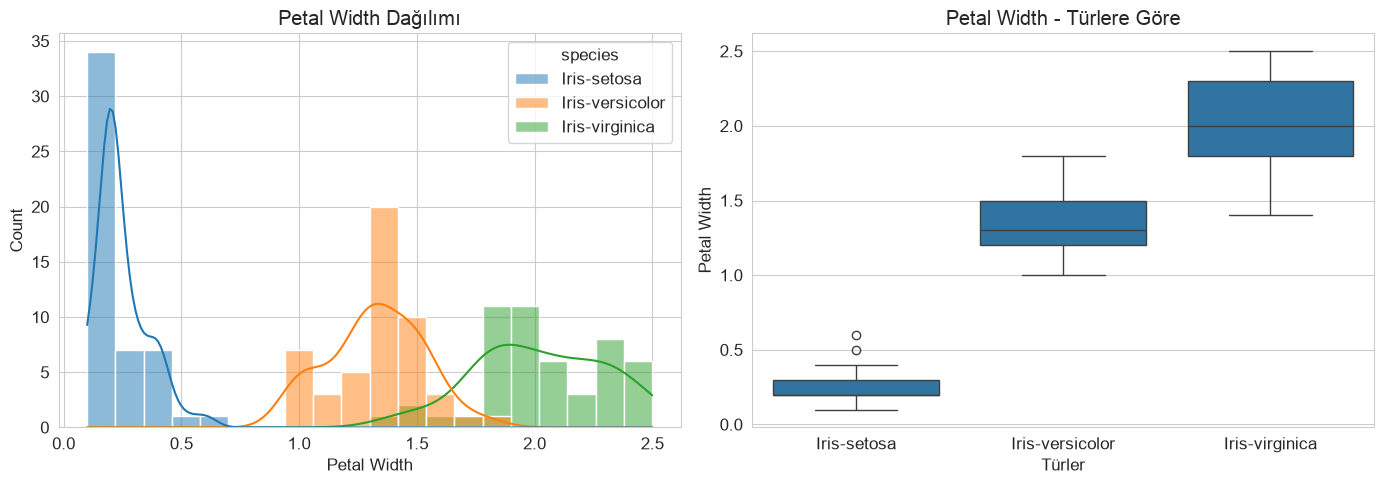

In [35]:


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sol grafik: dağılım
sns.histplot(
    data=df,
    x="petal_width",
    hue="species",
    bins=20,
    kde=True,
    ax=axes[0]
)
axes[0].set_title("Petal Width Dağılımı")
axes[0].set_xlabel("Petal Width")

# Sağ grafik: tür bazlı boxplot
sns.boxplot(
    data=df,
    x="species",
    y="petal_width",
    ax=axes[1]
)
axes[1].set_title("Petal Width - Türlere Göre")
axes[1].set_xlabel("Türler")
axes[1].set_ylabel("Petal Width")

plt.tight_layout()
plt.show()

In [36]:
# Basit regresyon için hedef ve özellik
X = df[['petal_width']]      # tek özellik
y = df['petal_length']       # hedef

# Veri ayrımı
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f'Eğitim seti boyutu: {X_train.shape[0]}')
print(f'Test seti boyutu: {X_test.shape[0]}')

Eğitim seti boyutu: 120
Test seti boyutu: 30


Kesim Noktası (β₀): 1.0822
Eğim (β₁): 2.2370
Model Denklemi:
petal_length = 1.0822 + 2.2370 × petal_width
R²: 0.9286
MAE: 0.3796


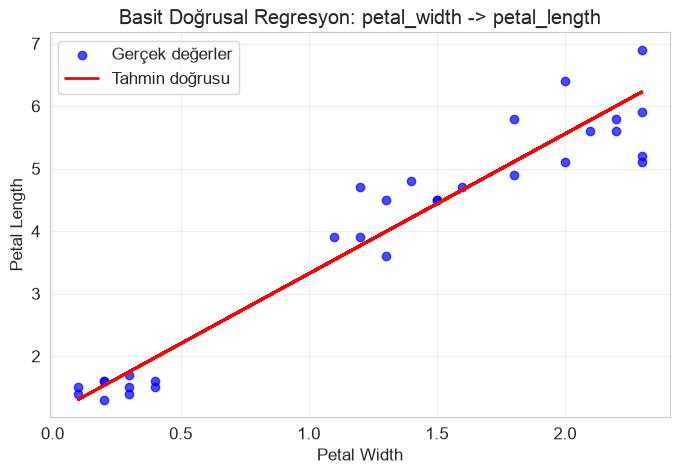

In [37]:
# Basit Doğrusal Regresyon örneği
# Hedef: petal_length
# Özellik: petal_width

X = df[['petal_width']]
y = df['petal_length']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model_simple = LinearRegression()
model_simple.fit(X_train, y_train)

y_pred_train = model_simple.predict(X_train)
y_pred_test = model_simple.predict(X_test)

beta_0 = model_simple.intercept_
beta_1 = model_simple.coef_[0]

#R² modeli açıklama gücü 1’e yaklaşırsa iyi 0’a yaklaşırsa zayıf
#MAEtahmin ile gerçek değer arasındaki ortalama fark küçükse iyi

print(f'Kesim Noktası (β₀): {beta_0:.4f}')
print(f'Eğim (β₁): {beta_1:.4f}')
print(f'Model Denklemi:')
print(f'petal_length = {beta_0:.4f} + {beta_1:.4f} × petal_width')

print(f'R²: {r2_score(y_test, y_pred_test):.4f}')
print(f'MAE: {mean_absolute_error(y_test, y_pred_test):.4f}')

plt.figure(figsize=(8, 5))
plt.scatter(X_test, y_test, color='blue', alpha=0.7, label='Gerçek değerler')
plt.plot(X_test, y_pred_test, color='red', linewidth=2, label='Tahmin doğrusu')
plt.xlabel('Petal Width')
plt.ylabel('Petal Length')
plt.title('Basit Doğrusal Regresyon: petal_width -> petal_length')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


In [38]:
# Gerçek ve tahmin edilen değerleri karşılaştır
sonuclar = pd.DataFrame({
    'Gerçek petal_length': y_test,
    'Tahmin edilen petal_length': y_pred_test,
    'Hata': y_test - y_pred_test
})

sonuclar['Mutlak Hata'] = sonuclar['Hata'].abs()
sonuclar = sonuclar.sort_index()

print('Test seti sonuçları:')
print(sonuclar.round(3).to_string())

Test seti sonuçları:
     Gerçek petal_length  Tahmin edilen petal_length   Hata  Mutlak Hata
9                    1.5                       1.306  0.194        0.194
12                   1.4                       1.306  0.094        0.094
18                   1.7                       1.753 -0.053        0.053
19                   1.5                       1.753 -0.253        0.253
26                   1.6                       1.977 -0.377        0.377
29                   1.6                       1.530  0.070        0.070
30                   1.6                       1.530  0.070        0.070
31                   1.5                       1.977 -0.477        0.477
36                   1.3                       1.530 -0.230        0.230
45                   1.4                       1.753 -0.353        0.353
55                   4.5                       3.990  0.510        0.510
56                   4.7                       4.661  0.039        0.039
64                   3.6      

In [39]:

## Ridge ve Lasso Regresyonu

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("IRIS.csv")

X = df[['sepal_length', 'sepal_width', 'petal_width']]
y = df['petal_length']
# Özellikler: petal_width, sepal_length, sepal_width
# Hedef: petal_length
X = df[['sepal_length', 'sepal_width', 'petal_width']]
y = df['petal_length']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Ridge ve Lasso için ölçeklendirme yapılır
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

models = {
    "LinearRegression": LinearRegression(),
    "Ridge(alpha=0.5)": Ridge(alpha=0.5),
    "Lasso(alpha=0.01)": Lasso(alpha=0.01)
}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    
    print(f"{name}")
    print(f"R²: {r2:.4f}")
    print(f"MAE: {mae:.4f}")
    print("-" * 40)


# Katsayıları görmek için Ridge ve Lasso ayrı ayrı inceleyelim
ridge_model = Ridge(alpha=0.5)
ridge_model.fit(X_train_scaled, y_train)

lasso_model = Lasso(alpha=0.01)
lasso_model.fit(X_train_scaled, y_train)

print("Ridge katsayıları:")
print(ridge_model.coef_)
print()

print("Lasso katsayıları:")
print(lasso_model.coef_)
print()

# Katsayılar sayesinde hangi değişken daha etkili?
feature_names = X.columns
for name, coef in zip(feature_names, lasso_model.coef_):
    print(f"{name}: {coef:.4f}")


LinearRegression
R²: 0.9604
MAE: 0.2606
----------------------------------------
Ridge(alpha=0.5)
R²: 0.9605
MAE: 0.2603
----------------------------------------
Lasso(alpha=0.01)
R²: 0.9605
MAE: 0.2589
----------------------------------------
Ridge katsayıları:
[ 0.59803385 -0.28672909  1.09197689]

Lasso katsayıları:
[ 0.5836677  -0.27578575  1.10195622]

sepal_length: 0.5837
sepal_width: -0.2758
petal_width: 1.1020


In [40]:
# Model performans metrikleri

""" RMSE: Eğitim 0.474, test 0.484
Modelin tahminleri gerçek petal_length değerlerinden yaklaşık 0.48 kadar sapıyor.

MAE: Eğitim 0.365, test 0.380
Model ortalama olarak yaklaşık 0.38 birim hata yapıyor.

R²: Eğitim 0.926, test 0.929
Model, petal_length değişiminin yaklaşık %93’ünü petal_width ile açıklıyor. """

rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
mae_train = mean_absolute_error(y_train, y_pred_train)
mae_test = mean_absolute_error(y_test, y_pred_test)
r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)

metrics = pd.DataFrame({
    'Metrik': ['RMSE', 'MAE', 'R²'],
    'Eğitim': [f'{rmse_train:.3f}', f'{mae_train:.3f}', f'{r2_train:.3f}'],
    'Test': [f'{rmse_test:.3f}', f'{mae_test:.3f}', f'{r2_test:.3f}']
})

print('Model Performansı:')
print(metrics.to_string(index=False))

Model Performansı:
Metrik Eğitim  Test
  RMSE  0.474 0.484
   MAE  0.365 0.380
    R²  0.926 0.929


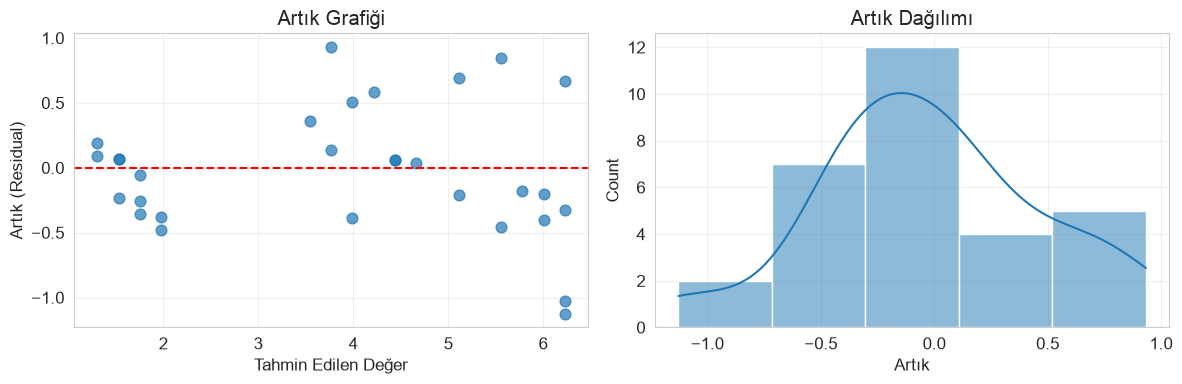

Artıkların ortalaması: -0.0250
Artıkların standart sapması: 0.4830


In [41]:
# Artık (Residual) analizi
residuals = y_test - y_pred_test

plt.figure(figsize=(12, 4))

# Tahminlere göre hata dağılımı
plt.subplot(1, 2, 1)
plt.scatter(y_pred_test, residuals, alpha=0.7, s=60)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Tahmin Edilen Değer')
plt.ylabel('Artık (Residual)')
plt.title('Artık Grafiği')
plt.grid(True, alpha=0.3)

# Hataların dağılımı
plt.subplot(1, 2, 2)
sns.histplot(residuals, bins=5, kde=True)
plt.xlabel('Artık')
plt.title('Artık Dağılımı')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'Artıkların ortalaması: {np.mean(residuals):.4f}')
print(f'Artıkların standart sapması: {np.std(residuals):.4f}')

In [42]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score
